# 📈 Meta-Labeling Pipeline for Trade Classification

This notebook applies the **two-stage ML / Meta-Labeling framework** (López de Prado, *Advances in Financial Machine Learning*) to predict whether a trade signal generated by a primary strategy will be profitable.

## 🏗️ Pipeline Overview

```
Stage 1 (Primary):   Breakout strategies → trade signals (entries/exits)
                                  ↓
Stage 2 (Meta):      ML classifier → P(trade is profitable)
                                  ↓
                     Filter / Size positions
```

## 🔑 Key Improvements vs. Standard ML

| Standard Approach (avoid) | This Notebook (correct) |
|---|---|
| `train_test_split(shuffle=True)` | Time-ordered train/test split |
| Random K-Fold CV | **Purged & Embargoed K-Fold** |
| Equal sample weights | **Sample uniqueness weights** |
| `next_5d_*` features | **No look-ahead** — features at entry only |
| SMOTE on time-series | `class_weight='balanced'` |
| Raw probability output | **Calibrated probabilities** |
| Accuracy as primary metric | **AUC + Precision @ threshold + Sharpe lift** |


# 1. Environment Setup

In [3]:
import sys
from pathlib import Path
backend_path = Path(__file__).parent.parent / "backend" if "__file__" in dir() else Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

In [4]:
import importlib
import os
import json
import warnings
import numpy as np
import pandas as pd
import vectorbt as vbt
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

In [5]:
from deltalake import DeltaTable
from dotenv import load_dotenv
load_dotenv()

MINIO_ENDPOINT = "192.168.1.30:9000"
AWS_ACCESS_KEY_ID = "CzOwnLkEDXQy951AOqes"
AWS_SECRET_ACCESS_KEY = "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S"

storage_options = {
    "AWS_ACCESS_KEY_ID": AWS_ACCESS_KEY_ID,
    "AWS_SECRET_ACCESS_KEY": AWS_SECRET_ACCESS_KEY,
    "AWS_ENDPOINT_URL": f"http://{MINIO_ENDPOINT}",
    "AWS_ALLOW_HTTP": "true",
    "AWS_EC2_METADATA_DISABLED": "true",
    "AWS_REGION": 'us-east-1',
    "aws_conditional_put": "etag",
}

# 2. Load Price Data

In [6]:
## Load datasource from deltalake and save it to local h5 file
REMOTE_HOST = "http://192.168.1.30:9000"
# REMOTE_HOST = "https://minio.phuchuynh.xyz"

from deltalake import DeltaTable
def load_stock_data() -> pd.DataFrame:
    """Load stock data from delta lake, ensuring index uniqueness to avoid unstack ValueError"""
    try:
        from deltalake import DeltaTable
        storage_options = {
            "AWS_ACCESS_KEY_ID": "CzOwnLkEDXQy951AOqes",
            "AWS_SECRET_ACCESS_KEY": "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
            "AWS_ENDPOINT_URL": REMOTE_HOST,
            "AWS_ALLOW_HTTP": "true",
            "AWS_EC2_METADATA_DISABLED": "true",
            "AWS_REGION": 'us-east-1',
            "aws_conditional_put": "etag",
        }        
        dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

        # Get data for last 2 years
        # Load watchlist symbols from CSV
        watchlist_path = "../backend/models/watchlist.csv"
        watchlist_df = pd.read_csv(watchlist_path)
        watchlist_symbols = watchlist_df.iloc[:, 0].values

        now = pd.Timestamp.now()
        start_date = now - pd.DateOffset(years=10)
        # Load all, then filter
        df = dt.to_pandas(
            filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)], 
            columns=["symbol", "date", "close", "open", "high", "low", "volume"]
        )
        
        # Remove duplicate (date, symbol) rows by keeping the last occurrence
        df = df.drop_duplicates(subset=["date", "symbol"], keep="last")
        # Convert to the same format as H5 store
        df = df.set_index(["date", "symbol"])
        stocks = df.unstack(level=1).bfill().ffill()
        
        print("Successfully loaded data from delta lake")
        return stocks
        
    except Exception as e:
        print(f"Error loading from delta lake: {e}")
        raise

import os
import pandas as pd

local_file = "stocks_data_latest.h5"
store_key = "stocks"

if os.path.exists(local_file):
    print(f"Loading stock data from local HDF5 file: {local_file}")
    with pd.HDFStore(local_file, mode="r") as store:
        df = store[store_key]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data()
    with pd.HDFStore(local_file, mode="w") as store:
        store.put(store_key, df)
    print(f"Stock data saved to {local_file}")

# Filter df to keep only columns for symbols in the watchlist (once)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_df = pd.read_csv(watchlist_path)
watchlist_symbols = watchlist_df.iloc[:, 0].values
stocks = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]
stocks


Loading stock data from local HDF5 file: stocks_data_latest.h5


close                                                               \
symbol       AAA    ABB    ACB    ACV   ADS    AGG    AGR    ANV    APH   ASM   
date                                                                            
2016-04-20  9.23   7.48   2.83  20.63  3.70  15.28   2.50   1.16  30.17  7.57   
2016-04-21  9.33   7.48   2.83  20.63  3.70  15.28   2.59   1.21  30.17  7.61   
2016-04-22  9.33   7.48   2.91  20.63  3.70  15.28   2.50   1.21  30.17  7.61   
2016-04-25  9.18   7.48   2.88  20.63  3.70  15.28   2.50   1.16  30.17  7.61   
2016-04-26  9.28   7.48   2.88  20.63  3.70  15.28   2.50   1.18  30.17  7.44   
...          ...    ...    ...    ...   ...    ...    ...    ...    ...   ...   
2026-04-13  7.01  14.60  23.75  46.30  8.64  13.00  14.95  24.35   5.56  5.86   
2026-04-14  7.10  14.60  24.00  46.40  9.07  12.90  15.05  24.90   5.58  5.94   
2026-04-15  7.12  14.50  23.80  46.70  9.11  12.95  14.95  24.45   5.62  5.89   
2026-04-16  7.04  14.60  23.65  46.30  9.12  12.80  14.90  24.75   5.57  5.80   
2026-04-17  7.03  14.60  23.75  45.90  9.09  12.90  14.85  25.00   5.58  5.77   

            ...       volume                                              \
symbol      ...      VNINDEX        VNM        VOS         VPB       VPG   
date        ...                                                            
2016-04-20  ...  108722464.0  1698460.0   154430.0  58299312.0    5000.0   
2016-04-21  ...  100005664.0   748780.0    82430.0  58299312.0    5000.0   
2016-04-22  ...  129717344.0   938560.0    94700.0  58299312.0    5000.0   
2016-04-25  ...  130331664.0   886480.0    58550.0  58299312.0    5000.0   
2016-04-26  ...  132638552.0   604360.0    87030.0  58299312.0    5000.0   
...         ...          ...        ...        ...         ...       ...   
2026-04-13  ...  767253440.0  3418300.0   876100.0  13557000.0  287600.0   
2026-04-14  ...  774260224.0  4247700.0   811900.0  14453500.0  316900.0   
2026-04-15  ...  804903616.0  4403200.0   935100.0  12229700.0  621100.0   
2026-04-16  ...  973731840.0  2272100.0  1491800.0  15412800.0  177000.0   
2026-04-17  ...  707285376.0  3115500.0  1314500.0  25668400.0  217700.0   

                                                                   
symbol            VPI         VRE        VSC       VTP        YEG  
date                                                               
2016-04-20     5000.0       800.0   156340.0     300.0     6100.0  
2016-04-21     5000.0       800.0    26330.0     300.0     6100.0  
2016-04-22     5000.0       800.0    67380.0     300.0     6100.0  
2016-04-25     5000.0       800.0    75940.0     300.0     6100.0  
2016-04-26     5000.0       800.0    36720.0     300.0     6100.0  
...               ...         ...        ...       ...        ...  
2026-04-13   738300.0   3915100.0  5244900.0  526500.0  2288200.0  
2026-04-14   833300.0   3851100.0  7001200.0  741600.0  1162000.0  
2026-04-15   633400.0  14406500.0  6993100.0  394500.0  1292300.0  
2026-04-16   635000.0  16443400.0  9699500.0  584900.0  1057800.0  
2026-04-17  5037500.0   7239000.0  4773900.0  258100.0   549200.0  

[2500 rows x 985 columns]

In [7]:
# Exclude VNINDEX from tradable universe (used as benchmark only)
symbols_in_columns = stocks.columns.get_level_values(1)
columns_to_keep_mask = symbols_in_columns != 'VNINDEX'
stocks_exclude_vnindex = stocks.loc[:, columns_to_keep_mask]

# 3. Compute Features from Raw OHLCV

Features are computed directly from `stocks_exclude_vnindex` using:
- `vbt.IndicatorFactory.from_talib` for standard TA (RSI, MFI, OBV, EMA, SMA, LINEARREG)
- Custom `_nb` Numba functions from `app.services.indicators` for YZ vol, z-score, AVWAP, relative strength
- Inline Numba Kalman filter for smoothed price (kf) and its z-scores

No Delta Lake / feature store dependency.

In [8]:
import numba as nb
from app.services.indicators import (
    avwap_func_nb,
    yang_zhang_volatility_nb,
    zscore_nb,
    relative_strength_nb,
    squeeze_ttm,
)

# ── Raw arrays ──────────────────────────────────────────────────────────────
close_df  = stocks_exclude_vnindex.close
open_df   = stocks_exclude_vnindex.open
high_df   = stocks_exclude_vnindex.high
low_df    = stocks_exclude_vnindex.low
volume_df = stocks_exclude_vnindex.volume

index   = close_df.index
symbols = close_df.columns

close_2d  = close_df.to_numpy().astype(np.float64)
open_2d   = open_df.to_numpy().astype(np.float64)
high_2d   = high_df.to_numpy().astype(np.float64)
low_2d    = low_df.to_numpy().astype(np.float64)
volume_2d = volume_df.to_numpy().astype(np.float64)

EPS = 1e-10

def _df(arr):
    """Wrap 2-D array into DataFrame with stock index/columns."""
    return pd.DataFrame(arr, index=index, columns=symbols)

def _safe_log_ratio_df(num_df, denom_df):
    """log1p((num - denom) / denom), NaN-safe."""
    safe = denom_df.where(denom_df != 0, np.nan)
    return np.log1p(((num_df - safe) / safe).clip(lower=-1 + EPS))

def _safe_log_ratio_2d(num, denom):
    safe = np.where(denom == 0, np.nan, denom)
    ratio = (num - safe) / safe
    return np.log1p(np.clip(ratio, -1 + EPS, None))


# ── 1. RSI (5, 14) ──────────────────────────────────────────────────────────
RSI = vbt.IndicatorFactory.from_talib('RSI')
rsi_5_df  = RSI.run(close_df, timeperiod=5).real
rsi_14_df = RSI.run(close_df, timeperiod=14).real

# ── 2. MFI (21) ─────────────────────────────────────────────────────────────
mfi_21_df = vbt.IndicatorFactory.from_talib('MFI').run(
    high_df, low_df, close_df, volume_df, timeperiod=21).real

# ── 3. OBV ──────────────────────────────────────────────────────────────────
obv_df = vbt.IndicatorFactory.from_talib('OBV').run(close_df, volume_df).real

# ── 4. Log return ────────────────────────────────────────────────────────────
log_return_df = np.log(close_df / close_df.shift(1))

# ── 5. EMA distances (10, 20, 50, 200) ──────────────────────────────────────
EMA = vbt.IndicatorFactory.from_talib('EMA')
ema_10_df  = EMA.run(close_df, timeperiod=10).real
ema_20_df  = EMA.run(close_df, timeperiod=20).real
ema_50_df  = EMA.run(close_df, timeperiod=50).real
ema_200_df = EMA.run(close_df, timeperiod=200).real

ema_10_dist  = _safe_log_ratio_df(close_df, ema_10_df)
ema_20_dist  = _safe_log_ratio_df(close_df, ema_20_df)
ema_50_dist  = _safe_log_ratio_df(close_df, ema_50_df)
ema_200_dist = _safe_log_ratio_df(close_df, ema_200_df)

# ── 6. Volume MA ratio (10, 20) ──────────────────────────────────────────────
SMA = vbt.IndicatorFactory.from_talib('SMA')
vol_ma_10_dist = _safe_log_ratio_df(volume_df, SMA.run(volume_df, timeperiod=10).real)
vol_ma_20_dist = _safe_log_ratio_df(volume_df, SMA.run(volume_df, timeperiod=20).real)

# ── 7. EFI z-score (Elder Force Index = close.diff * volume) ────────────────
efi_2d = np.nan_to_num((close_df.diff() * volume_df).to_numpy().astype(np.float64))
efi_zscore_10_2d = zscore_nb(efi_2d, window=10)
efi_zscore_20_2d = zscore_nb(efi_2d, window=20)

# ── 8. AVWAP distances (anchored to rolling highest / lowest) ────────────────
avwap_hi_2d = avwap_func_nb(close_2d, high_2d, low_2d, volume_2d, is_highest=True,  window=200)
avwap_lo_2d = avwap_func_nb(close_2d, high_2d, low_2d, volume_2d, is_highest=False, window=200)
vwap_dist_hi_2d = _safe_log_ratio_2d(close_2d, avwap_hi_2d)
vwap_dist_lo_2d = _safe_log_ratio_2d(close_2d, avwap_lo_2d)

# ── 9. Relative strength vs VNINDEX (10, 20) ─────────────────────────────────
vnindex_2d = np.tile(
    stocks.close['VNINDEX'].values.reshape(-1, 1).astype(np.float64),
    (1, close_2d.shape[1]),
)
rs_10_2d, mrs_10_2d = relative_strength_nb(close_2d, vnindex_2d, window=10)
rs_20_2d, mrs_20_2d = relative_strength_nb(close_2d, vnindex_2d, window=20)

# ── 10. Cross-sectional MSR rank ─────────────────────────────────────────────
msr_rank_10_2d = _df(mrs_10_2d).rank(axis=1, pct=True).to_numpy()
msr_rank_20_2d = _df(mrs_20_2d).rank(axis=1, pct=True).to_numpy()

# ── 11. Z-score of log return (10, 20) ───────────────────────────────────────
lr_2d = np.nan_to_num(log_return_df.to_numpy().astype(np.float64))
zscore_lr_10_2d = zscore_nb(lr_2d, window=10)
zscore_lr_20_2d = zscore_nb(lr_2d, window=20)

# ── 12. Yang-Zhang volatility (10, 20) ───────────────────────────────────────
# signature: yang_zhang_volatility_nb(close, open, high, low, window, periods)
yz_vol_10_2d = yang_zhang_volatility_nb(close_2d, open_2d, high_2d, low_2d, window=10, periods=252).astype(np.float64)
yz_vol_20_2d = yang_zhang_volatility_nb(close_2d, open_2d, high_2d, low_2d, window=20, periods=252).astype(np.float64)

# ── 13. DC TMV — TTM Squeeze momentum value ──────────────────────────────────
# squeeze_ttm uses vbt.IndicatorFactory.from_talib internally → handles 2-D DataFrames
_diff, dc_tmv_raw = squeeze_ttm(
    close_df.to_numpy(), high_df.to_numpy(), low_df.to_numpy(),
    bb_period=10, bb_mult=1.2, bb_matype=3,
    kc_period=10, kc_mult=1.2,
    donichan_period=10, osc_smoothing_period=10,
)
# squeeze_ttm receives ndarray → vbt wraps columns per param combo → result may be 3-D
# If 2-D pass-through, take as-is; if 1 param-combo dim, squeeze it out
if hasattr(dc_tmv_raw, 'to_numpy'):
    dc_tmv_2d = dc_tmv_raw.to_numpy()
else:
    dc_tmv_2d = np.asarray(dc_tmv_raw)
if dc_tmv_2d.ndim == 3:
    dc_tmv_2d = dc_tmv_2d[:, :, 0]  # drop single param-combo axis

# ── 14. Kalman-filter smoothed price → distance + z-scores ───────────────────
@nb.njit(parallel=True)
def _kalman_2d(prices, obs_cov=1.0, trans_cov=0.01):
    """Scalar Kalman filter applied independently to each column."""
    T, S = prices.shape
    out = np.empty_like(prices)
    for j in nb.prange(S):
        x = prices[0, j]
        p = 1.0
        for i in range(T):
            p_pred = p + trans_cov
            gain   = p_pred / (p_pred + obs_cov)
            x      = x + gain * (prices[i, j] - x)
            p      = (1.0 - gain) * p_pred
            out[i, j] = x
    return out

kf_2d          = _kalman_2d(close_2d)
kf_dist_2d     = _safe_log_ratio_2d(close_2d, kf_2d)
zscore_kf_10_2d = zscore_nb(kf_2d, window=10)
zscore_kf_20_2d = zscore_nb(kf_2d, window=20)


# ── Assemble features_df (date × symbol long form) ──────────────────────────
_feat_arrays = {
    'rsi_window_5':           rsi_5_df.to_numpy(),
    'rsi_window_14':          rsi_14_df.to_numpy(),
    'mfi_21':                 mfi_21_df.to_numpy(),
    'obv':                    obv_df.to_numpy(),
    'log_return':             log_return_df.to_numpy(),
    'volume_threshold_ma_10': vol_ma_10_dist.to_numpy(),
    'volume_threshold_ma_20': vol_ma_20_dist.to_numpy(),
    'ema_10_distance':        ema_10_dist.to_numpy(),
    'ema_20_distance':        ema_20_dist.to_numpy(),
    'ema_50_distance':        ema_50_dist.to_numpy(),
    'ema_200_distance':       ema_200_dist.to_numpy(),
    'vwap_distance_highest':  vwap_dist_hi_2d,
    'vwap_distance_lowest':   vwap_dist_lo_2d,
    'efi_zscore_10':          efi_zscore_10_2d,
    'efi_zscore_20':          efi_zscore_20_2d,
    'rs_10':                  rs_10_2d,
    'rs_20':                  rs_20_2d,
    'mrs_10':                 mrs_10_2d,
    'mrs_20':                 mrs_20_2d,
    'msr_rank_10':            msr_rank_10_2d,
    'msr_rank_20':            msr_rank_20_2d,
    'zscore_10_log_return':   zscore_lr_10_2d,
    'zscore_20_log_return':   zscore_lr_20_2d,
    'yz_vol_10':              yz_vol_10_2d,
    'yz_vol_20':              yz_vol_20_2d,
    'dc_tmv':                 dc_tmv_2d,
    'kf_distance':            kf_dist_2d,
    'zscore_kf_10':           zscore_kf_10_2d,
    'zscore_kf_20':           zscore_kf_20_2d,
    # keep close for downstream kf_distance sanity checks (excluded from SAFE_FEATURE_COLS)
    'close':                  close_2d,
}

features_df = pd.concat(
    [_df(arr).stack().rename(feat) for feat, arr in _feat_arrays.items()],
    axis=1,
)
features_df.index.names = ['date', 'symbol']

print(f"Features computed: {features_df.shape[1]} columns × {len(features_df):,} rows")
print(f"Date range: {features_df.index.get_level_values('date').min()} "
      f"→ {features_df.index.get_level_values('date').max()}")
print(list(features_df.columns))


Features computed: 30 columns × 490,000 rows
Date range: 2016-04-20 00:00:00 → 2026-04-17 00:00:00
['rsi_window_5', 'rsi_window_14', 'mfi_21', 'obv', 'log_return', 'volume_threshold_ma_10', 'volume_threshold_ma_20', 'ema_10_distance', 'ema_20_distance', 'ema_50_distance', 'ema_200_distance', 'vwap_distance_highest', 'vwap_distance_lowest', 'efi_zscore_10', 'efi_zscore_20', 'rs_10', 'rs_20', 'mrs_10', 'mrs_20', 'msr_rank_10', 'msr_rank_20', 'zscore_10_log_return', 'zscore_20_log_return', 'yz_vol_10', 'yz_vol_20', 'dc_tmv', 'kf_distance', 'zscore_kf_10', 'zscore_kf_20', 'close']


# 4. Generate Trade Signals (Primary Model)

This is your existing breakout strategy — the **primary model** in the meta-labeling framework. It decides *which trades to take*. The meta-model below will decide *whether each trade is worth taking*.


In [9]:
from app.services.strategies import BreakoutTTMVersion2

# Best params from backtest_service.py
# V1: Trial #453 — Total Return 403%, Sortino 0.995
# V2: Trial #493 — Total Return 397%, Sortino 1.001
PARAM_NAMES = [
    'bb_window', 'bb_multiplier', 'kc_window', 'kc_multiplier',
    'atr_window', 'momentum_window', 'donichan_window', 'entry_version',
    'kc_atr_period', 'osc_smoothing_period', 'matype',
    'william_vix_period', 'consecutive_neg_threshold',
]

strategy_params = [
    (14, 1.0, 51, 1.2, 11, 12,  9, 'v1', 7, 11, 0, 22, 14),  # V1
    (18, 1.2, 53, 1.5,  5, 12,  9, 'v2', 5, 11, 0, 27, 13),  # V2
]

total_trades = pd.DataFrame()
total_open_trades = pd.DataFrame()

for params in strategy_params:
    param_dict = dict(zip(PARAM_NAMES, params))
    # move entry_version to front (cosmetic, matches backtest_service convention)
    entry_version = param_dict.pop('entry_version')
    param_dict = {'entry_version': entry_version, **param_dict}

    breakout_strategy = BreakoutTTMVersion2(stocks_exclude_vnindex, **param_dict)
    portfolio = breakout_strategy.get_portfolio()
    print(f"Params: {param_dict}")
    # sharpe_ratio() returns a Series (one per symbol-group) — take mean
    sharpe_val = float(portfolio.sharpe_ratio().mean())
    trade_count = int(portfolio.trades.count().sum())
    print(f"Sharpe (mean across groups): {sharpe_val:.3f}, Trades: {trade_count}")

    trades = pd.DataFrame(portfolio.trades.records)
    trades['metadata'] = json.dumps(param_dict)
    open_trade = pd.DataFrame(portfolio.trades.open.records)
    open_trade['metadata'] = json.dumps(param_dict)

    total_trades = pd.concat([total_trades, trades])
    total_open_trades = pd.concat([total_open_trades, open_trade])

total_trades['type'] = 'closed_trades'
total_open_trades['type'] = 'open_trades'

# Filter: keep closed trades that are not also in open trades
open_trade_keys = pd.MultiIndex.from_frame(total_open_trades[['col', 'entry_idx']])
total_trade_keys = pd.MultiIndex.from_frame(total_trades[['col', 'entry_idx']])
mask = ~total_trade_keys.isin(open_trade_keys)
filtered_total_trades = total_trades[mask]

# Combine closed + open
all_trades_df = pd.concat([filtered_total_trades, total_open_trades])
all_trades_df = (
    all_trades_df
    .drop_duplicates(subset=['col', 'entry_idx'], keep='first')
    .reset_index(drop=True)
)
# col maps to stocks_exclude_vnindex (not stocks — VNINDEX was removed)
all_trades_df['symbol'] = all_trades_df.apply(
    lambda x: stocks_exclude_vnindex.close.columns[x['col']], axis=1)
all_trades_df['entry_date'] = all_trades_df.apply(
    lambda x: stocks_exclude_vnindex.index[x['entry_idx']], axis=1)
all_trades_df['exit_date'] = all_trades_df.apply(
    lambda x: stocks_exclude_vnindex.index[min(int(x['exit_idx']), len(stocks_exclude_vnindex) - 1)]
              if pd.notna(x['exit_idx']) else stocks_exclude_vnindex.index[-1],
    axis=1,
)
all_trades_df['date'] = all_trades_df['entry_date']  # alias for merging
print(f"\nTotal trades generated: {len(all_trades_df)}")
print(f"Closed: {(all_trades_df['type']=='closed_trades').sum()}, "
      f"Open: {(all_trades_df['type']=='open_trades').sum()}")


Params: {'entry_version': 'v1', 'bb_window': 14, 'bb_multiplier': 1.0, 'kc_window': 51, 'kc_multiplier': 1.2, 'atr_window': 11, 'momentum_window': 12, 'donichan_window': 9, 'kc_atr_period': 7, 'osc_smoothing_period': 11, 'matype': 0, 'william_vix_period': 22, 'consecutive_neg_threshold': 14}
Sharpe (mean across groups): 0.697, Trades: 11746
Params: {'entry_version': 'v2', 'bb_window': 18, 'bb_multiplier': 1.2, 'kc_window': 53, 'kc_multiplier': 1.5, 'atr_window': 5, 'momentum_window': 12, 'donichan_window': 9, 'kc_atr_period': 5, 'osc_smoothing_period': 11, 'matype': 0, 'william_vix_period': 27, 'consecutive_neg_threshold': 13}
Sharpe (mean across groups): 0.679, Trades: 12195

Total trades generated: 15435
Closed: 15228, Open: 207


# 5. Define Labels (with Transaction Costs & Threshold)

## ⚠️ Improvement over Original

Original used: `Y = return > 0` — too lenient, includes marginal trades.

New definition includes:
- **Transaction costs** (round-trip ~0.3% in VN market)
- **Minimum return threshold** to filter marginally profitable trades
- This forces the model to identify *clearly* profitable setups


Total closed trades: 15228
Label distribution:
Y
Loss/Marginal    0.615117
Clear Win        0.384883
Name: proportion, dtype: float64

Mean net return (winners):  16.349%
Mean net return (losers):    -5.514%


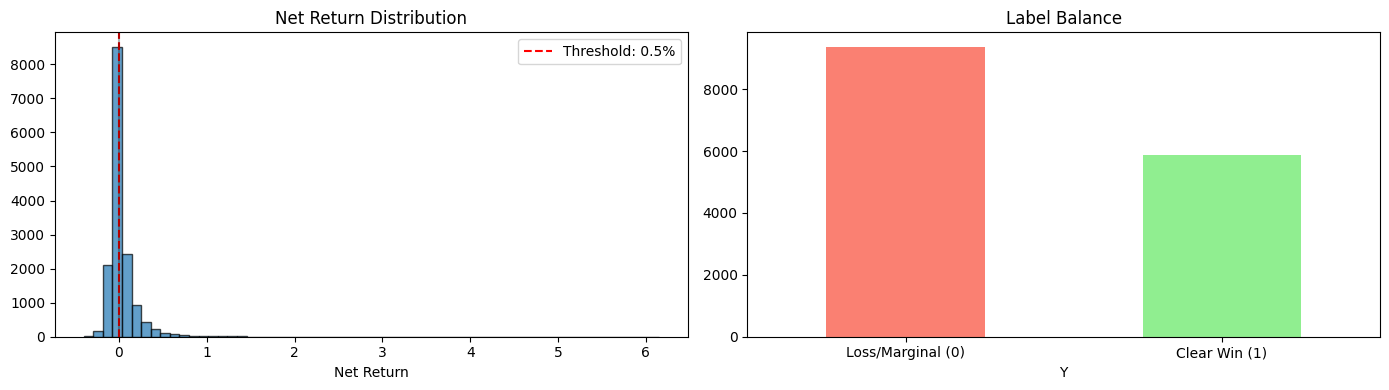

In [10]:
# === Label Configuration ===
ROUND_TRIP_COST   = 0.003   # 30 bps round-trip (entry + exit fees)
MIN_RETURN_EDGE   = 0.005   # require at least 50 bps net edge
LABEL_THRESHOLD   = ROUND_TRIP_COST + MIN_RETURN_EDGE  # ~0.8%

# Filter out open trades (no realized return) for training
closed_trades = all_trades_df[all_trades_df['type'] == 'closed_trades'].copy()

# Net return after costs
closed_trades['net_return'] = closed_trades['return'] - ROUND_TRIP_COST

# Binary label: 1 if net return > threshold, else 0
closed_trades['Y'] = (closed_trades['net_return'] > MIN_RETURN_EDGE).astype(int)

# Sort by entry_date — CRITICAL for time-series ordering
closed_trades = closed_trades.sort_values('entry_date').reset_index(drop=True)

print(f"Total closed trades: {len(closed_trades)}")
print(f"Label distribution:")
print(closed_trades['Y'].value_counts(normalize=True).rename({0: 'Loss/Marginal', 1: 'Clear Win'}))
print(f"\nMean net return (winners):  {closed_trades.loc[closed_trades.Y==1, 'net_return'].mean():.3%}")
print(f"Mean net return (losers):    {closed_trades.loc[closed_trades.Y==0, 'net_return'].mean():.3%}")

# Plot return distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(closed_trades['net_return'], bins=60, edgecolor='black', alpha=0.7)
ax[0].axvline(MIN_RETURN_EDGE, color='red', linestyle='--', label=f'Threshold: {MIN_RETURN_EDGE:.1%}')
ax[0].axvline(0, color='black', linestyle='-', alpha=0.3)
ax[0].set_title('Net Return Distribution')
ax[0].set_xlabel('Net Return')
ax[0].legend()

closed_trades['Y'].value_counts().plot(kind='bar', ax=ax[1], color=['salmon', 'lightgreen'])
ax[1].set_title('Label Balance')
ax[1].set_xticklabels(['Loss/Marginal (0)', 'Clear Win (1)'], rotation=0)
plt.tight_layout()
plt.show()

# 6. Merge Features at Entry Time

We merge features computed **at entry date** for each trade. Since features in `features_df` are already point-in-time (rolling windows on past data), merging on `(date, symbol)` is safe **as long as we exclude any `next_*` columns**.


In [11]:
features_df_reset = features_df.reset_index()

# 🚨 Exclude any look-ahead columns by name pattern
SAFE_FEATURE_COLS = [
    c for c in features_df_reset.columns
    if not c.startswith('next_') and c not in ['open', 'high', 'low', 'close', 'volume']
]

print(f"Safe (no look-ahead) features: {len(SAFE_FEATURE_COLS) - 2}")  # -2 for date, symbol

# Merge
training_df = pd.merge(
    closed_trades[['symbol', 'date', 'entry_date', 'exit_date',
                   'return', 'net_return', 'Y']],
    features_df_reset[SAFE_FEATURE_COLS],
    left_on=['date', 'symbol'],
    right_on=['date', 'symbol'],
    how='inner',
)

# Sort by entry date AGAIN (post-merge)
training_df = training_df.sort_values('entry_date').reset_index(drop=True)
training_df = training_df.dropna()

print(f"\nFinal training rows: {len(training_df)}")
print(f"Date range: {training_df['entry_date'].min()} → {training_df['entry_date'].max()}")

Safe (no look-ahead) features: 29

Final training rows: 14296
Date range: 2017-02-06 00:00:00 → 2026-04-06 00:00:00


In [12]:
# === Feature selection — REMOVED all next_* features ===
training_feature_columns = [
    # Momentum / oscillators
    'rsi_window_5', 'rsi_window_14', 'mfi_21',

    # Volume / flow
    'obv', 'volume_threshold_ma_10', 'volume_threshold_ma_20',
    'efi_zscore_10', 'efi_zscore_20',

    # Price-relative-to-MA (stationary)
    'ema_10_distance', 'ema_20_distance', 'ema_50_distance', 'ema_200_distance',
    'kf_distance', 'zscore_kf_10', 'zscore_kf_20',

    # VWAP context (entry-time only — no next_*)
    'vwap_distance_highest', 'vwap_distance_lowest',

    # Cross-sectional / relative strength
    'mrs_10', 'mrs_20', 'rs_10', 'rs_20',
    'msr_rank_10', 'msr_rank_20',

    # Volatility & log returns
    'zscore_10_log_return', 'zscore_20_log_return',
    'yz_vol_10', 'yz_vol_20',

    # Donchian / squeeze
    'dc_tmv',
]

# Filter to only columns that actually exist
training_feature_columns = [c for c in training_feature_columns if c in training_df.columns]
print(f"Final feature count: {len(training_feature_columns)}")
print(training_feature_columns)

Final feature count: 28
['rsi_window_5', 'rsi_window_14', 'mfi_21', 'obv', 'volume_threshold_ma_10', 'volume_threshold_ma_20', 'efi_zscore_10', 'efi_zscore_20', 'ema_10_distance', 'ema_20_distance', 'ema_50_distance', 'ema_200_distance', 'kf_distance', 'zscore_kf_10', 'zscore_kf_20', 'vwap_distance_highest', 'vwap_distance_lowest', 'mrs_10', 'mrs_20', 'rs_10', 'rs_20', 'msr_rank_10', 'msr_rank_20', 'zscore_10_log_return', 'zscore_20_log_return', 'yz_vol_10', 'yz_vol_20', 'dc_tmv']


In [ ]:
# === Export for loser autopsy notebook ===
_autopsy_path = 'all_trades_with_features.h5'
training_df.to_hdf(_autopsy_path, key='data', mode='w', complevel=5)
print(f"Saved {len(training_df)} rows → {_autopsy_path}")
print(f"Columns: {list(training_df.columns)}")

# 7. Time-Ordered Train/Test Split

## 🚨 Most Critical Fix

**Original notebook:**
```python
train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)  # WRONG!
```

This randomly mixes time periods — your model trains on 2023 data and tests on 2018 data, which is **future-leakage in reverse**. Backtest results look great but live trading collapses.

**Correct approach:** Split chronologically. Train on past, test on future.


In [13]:
# === Chronological split (no shuffle!) ===
TRAIN_END_DATE = '2022-06-30'   # ~80/20 split (2014-2022 train, 2022-2023 test)
EMBARGO_DAYS   = 10              # gap between train and test

train_mask = training_df['entry_date'] <= pd.Timestamp(TRAIN_END_DATE)
embargo_start = pd.Timestamp(TRAIN_END_DATE)
embargo_end   = embargo_start + pd.Timedelta(days=EMBARGO_DAYS)
test_mask = training_df['entry_date'] > embargo_end

X_train = training_df.loc[train_mask, training_feature_columns].copy()
y_train = training_df.loc[train_mask, 'Y'].copy()
X_test  = training_df.loc[test_mask,  training_feature_columns].copy()
y_test  = training_df.loc[test_mask,  'Y'].copy()
returns_test = training_df.loc[test_mask, 'net_return'].copy()
dates_train  = training_df.loc[train_mask, 'entry_date'].copy()
dates_test   = training_df.loc[test_mask,  'entry_date'].copy()
exit_dates_train = training_df.loc[train_mask, 'exit_date'].copy()

print(f"Train period: {dates_train.min()} → {dates_train.max()} ({len(X_train)} trades)")
print(f"  → Embargo: {embargo_start.date()} to {embargo_end.date()} ({EMBARGO_DAYS} days)")
print(f"Test period:  {dates_test.min()} → {dates_test.max()} ({len(X_test)} trades)")
print(f"\nTrain label balance: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Test label balance:  {y_test.value_counts(normalize=True).to_dict()}")

Train period: 2017-02-06 00:00:00 → 2022-06-30 00:00:00 (8151 trades)
  → Embargo: 2022-06-30 to 2022-07-10 (10 days)
Test period:  2022-07-12 00:00:00 → 2026-04-06 00:00:00 (6122 trades)

Train label balance: {0: 0.6021347073978653, 1: 0.3978652926021347}
Test label balance:  {0: 0.6323097027115322, 1: 0.3676902972884678}


In [14]:
# === Scaling — fit on train ONLY, transform test ===
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

# 🚨 NOTE: We do NOT use SMOTE.
# SMOTE creates synthetic samples by interpolating between neighbors —
# this doesn't make sense for time-series financial data and can leak info.
# Instead, we use class_weight='balanced' or scale_pos_weight in models.

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

X_train_scaled: (8151, 28)
X_test_scaled:  (6122, 28)


# 8. Compute Sample Uniqueness Weights

When trades have **overlapping holding periods**, their labels are not independent — they share return information. López de Prado's solution: **down-weight overlapping samples** during training.


In [15]:
def compute_sample_uniqueness(entry_dates: pd.Series, exit_dates: pd.Series) -> np.ndarray:
    """
    Compute López de Prado's sample uniqueness:
    For each sample, count how many other samples' [entry, exit] intervals overlap with it.
    Weight = 1 / overlap_count (then normalized).
    """
    n = len(entry_dates)
    entries = entry_dates.values
    exits   = exit_dates.values
    overlaps = np.zeros(n)

    for i in range(n):
        # Count concurrent samples (including self)
        overlaps[i] = ((entries <= exits[i]) & (exits >= entries[i])).sum()

    weights = 1.0 / np.maximum(overlaps, 1)
    return weights / weights.mean()  # normalize to mean=1


train_weights = compute_sample_uniqueness(
    dates_train.reset_index(drop=True),
    exit_dates_train.reset_index(drop=True),
)

print(f"Train sample weights:")
print(f"  min:    {train_weights.min():.3f}")
print(f"  median: {np.median(train_weights):.3f}")
print(f"  max:    {train_weights.max():.3f}")
print(f"  Effective sample size: {(train_weights.sum())**2 / (train_weights**2).sum():.0f} / {len(train_weights)}")

Train sample weights:
  min:    0.038
  median: 0.958
  max:    5.160
  Effective sample size: 6878 / 8151


# 9. Purged & Embargoed K-Fold Cross-Validation

## Why?

Standard `KFold` randomly shuffles → leakage.
Standard `TimeSeriesSplit` doesn't purge overlapping samples.

**Purged & Embargoed K-Fold** (López de Prado, AFML Ch. 7):
- Splits data chronologically
- **Purges** training samples whose holding period overlaps the test set
- **Embargo**: removes samples right after the test fold to prevent serial-correlation leakage


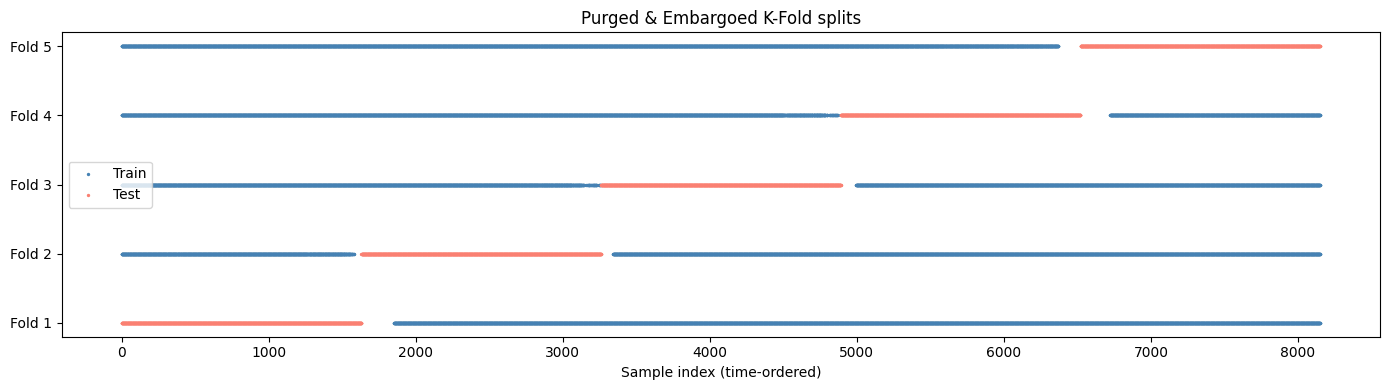

In [16]:
class PurgedKFold:
    """
    Purged & Embargoed K-Fold for time-series with overlapping labels.

    Parameters
    ----------
    n_splits : int
    entry_dates : pd.Series of trade entry timestamps
    exit_dates  : pd.Series of trade exit timestamps
    embargo_pct : float, fraction of dataset to embargo after each test fold
    """
    def __init__(self, n_splits=5, entry_dates=None, exit_dates=None, embargo_pct=0.01):
        self.n_splits    = n_splits
        self.entry_dates = entry_dates.reset_index(drop=True)
        self.exit_dates  = exit_dates.reset_index(drop=True)
        self.embargo_pct = embargo_pct

    def split(self, X, y=None, groups=None):
        n = len(X)
        indices = np.arange(n)
        embargo_n = int(n * self.embargo_pct)

        # Test folds are contiguous chunks ordered in time
        test_ranges = np.array_split(indices, self.n_splits)

        for test_idx in test_ranges:
            test_start_t = self.entry_dates.iloc[test_idx[0]]
            test_end_t   = self.exit_dates.iloc[test_idx[-1]]

            train_mask = np.ones(n, dtype=bool)
            train_mask[test_idx] = False

            # Purge: remove training samples whose [entry, exit] overlaps test period
            for i in indices[train_mask]:
                if (self.entry_dates.iloc[i] <= test_end_t) and \
                   (self.exit_dates.iloc[i]  >= test_start_t):
                    train_mask[i] = False

            # Embargo: remove samples right after test fold
            embargo_end = min(test_idx[-1] + 1 + embargo_n, n)
            train_mask[test_idx[-1]+1 : embargo_end] = False

            train_idx = indices[train_mask]
            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


# === Build CV splitter for training set ===
purged_cv = PurgedKFold(
    n_splits=5,
    entry_dates=dates_train,
    exit_dates=exit_dates_train,
    embargo_pct=0.01,
)

# Sanity check: visualize splits
fig, ax = plt.subplots(figsize=(14, 4))
for fold, (tr, te) in enumerate(purged_cv.split(X_train_scaled)):
    ax.scatter(tr, [fold]*len(tr), c='steelblue', s=2, label='Train' if fold==0 else None)
    ax.scatter(te, [fold]*len(te), c='salmon',    s=2, label='Test'  if fold==0 else None)
ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel('Sample index (time-ordered)')
ax.set_title('Purged & Embargoed K-Fold splits')
ax.legend()
plt.tight_layout()
plt.show()

# 10. Evaluation Helpers

We evaluate models with metrics that matter for **trading P&L**, not just classification accuracy:
- **AUC** — discrimination ability
- **Precision @ threshold** — how often "predicted win" is actually a win
- **Sharpe lift** — improvement in risk-adjusted return when using model as a filter
- **Trade reduction** — % of bad trades successfully filtered


In [17]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, brier_score_loss,
)


def evaluate_meta_model(
    y_true: pd.Series,
    y_proba: np.ndarray,
    returns: pd.Series,
    threshold: float = 0.55,
) -> dict:
    """Compute trading-relevant evaluation metrics."""
    y_pred = (y_proba >= threshold).astype(int)

    # Filter strategy returns: only take trades where model says "win"
    take_mask = y_pred == 1
    base_returns     = returns
    filtered_returns = returns[take_mask]

    def sharpe(r):
        return r.mean() / (r.std() + 1e-9) * np.sqrt(252) if len(r) > 1 else 0

    metrics = {
        'auc':              roc_auc_score(y_true, y_proba),
        'brier_score':      brier_score_loss(y_true, y_proba),
        'precision':        precision_score(y_true, y_pred, zero_division=0),
        'recall':           recall_score(y_true, y_pred, zero_division=0),
        'f1':               f1_score(y_true, y_pred, zero_division=0),
        'trades_taken':     int(take_mask.sum()),
        'trades_filtered':  int((~take_mask).sum()),
        'pct_filtered':     float((~take_mask).mean()),
        'base_mean_ret':    float(base_returns.mean()),
        'filt_mean_ret':    float(filtered_returns.mean()) if len(filtered_returns) else 0,
        'base_sharpe':      sharpe(base_returns),
        'filt_sharpe':      sharpe(filtered_returns) if len(filtered_returns) > 1 else 0,
    }
    metrics['sharpe_lift'] = metrics['filt_sharpe'] - metrics['base_sharpe']
    return metrics


def plot_evaluation(model_name, y_true, y_proba, returns, threshold=0.55):
    metrics = evaluate_meta_model(y_true, y_proba, returns, threshold)
    y_pred = (y_proba >= threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Loss', 'Pred Win'],
                yticklabels=['Actual Loss', 'Actual Win'])
    axes[0].set_title(f'{model_name} — Confusion @ thr={threshold}')

    # Probability distribution
    axes[1].hist(y_proba[y_true==0], bins=30, alpha=0.5, label='Actual Loss', color='red')
    axes[1].hist(y_proba[y_true==1], bins=30, alpha=0.5, label='Actual Win',  color='green')
    axes[1].axvline(threshold, color='black', linestyle='--', label=f'thr={threshold}')
    axes[1].set_xlabel('Predicted P(win)')
    axes[1].set_title(f'{model_name} — Probability Distribution')
    axes[1].legend()

    # Returns: filtered vs base
    rets_base = returns
    rets_filt = returns[y_pred==1]
    axes[2].hist(rets_base, bins=40, alpha=0.4, label=f'All (μ={rets_base.mean():.2%})', color='gray')
    if len(rets_filt) > 0:
        axes[2].hist(rets_filt, bins=40, alpha=0.6,
                     label=f'Filtered (μ={rets_filt.mean():.2%})', color='green')
    axes[2].axvline(0, color='black', linestyle='-', alpha=0.3)
    axes[2].set_xlabel('Net Return')
    axes[2].set_title(f'{model_name} — Return Distributions')
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    return metrics

# 11. Train XGBoost with Purged CV + Optuna

Tuning uses our purged CV splitter — no leakage.


In [18]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV

# Class imbalance handler
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / max(n_pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.3f}")


def objective_xgb(trial):
    params = {
        'objective':       'binary:logistic',
        'eval_metric':     'auc',
        'n_estimators':    trial.suggest_int('n_estimators', 100, 600, step=50),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':       trial.suggest_int('max_depth', 3, 7),         # shallow!
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':           trial.suggest_float('gamma', 0, 5),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state':    42,
        'verbosity':       0,
    }
    model = XGBClassifier(**params)

    # ⭐ Use purged CV (not random)
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=purged_cv.split(X_train_scaled),  # custom splits
        scoring='roc_auc',
        n_jobs=-1,
        params={'sample_weight': train_weights},
    )
    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=80, show_progress_bar=True)

print("\nBest XGBoost params:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV AUC: {study_xgb.best_value:.4f}")

[I 2026-04-30 22:55:46,919] A new study created in memory with name: no-name-4c4ab1cb-a802-472f-b994-1cfd6c5ae280


scale_pos_weight = 1.513


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-04-30 22:55:49,117] Trial 0 finished with value: 0.49328012933476373 and parameters: {'n_estimators': 300, 'learning_rate': 0.17254716573280354, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973, 'reg_alpha': 0.08499808989183001, 'reg_lambda': 0.0006440507553993703}. Best is trial 0 with value: 0.49328012933476373.
[I 2026-04-30 22:55:51,020] Trial 1 finished with value: 0.5039786206960187 and parameters: {'n_estimators': 450, 'learning_rate': 0.010636066512540286, 'max_depth': 7, 'min_child_weight': 9, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.9170225492671691, 'reg_alpha': 2.716051144654844e-06, 'reg_lambda': 0.00015777981883364995}. Best is trial 1 with value: 0.5039786206960187.
[I 2026-04-30 22:55:52,652] Trial 2 finished with value: 0.49732675939301896 and parameters: {'n_estimators': 300, 'learning_rate': 0.023927528765580634, 'max_depth': 6,

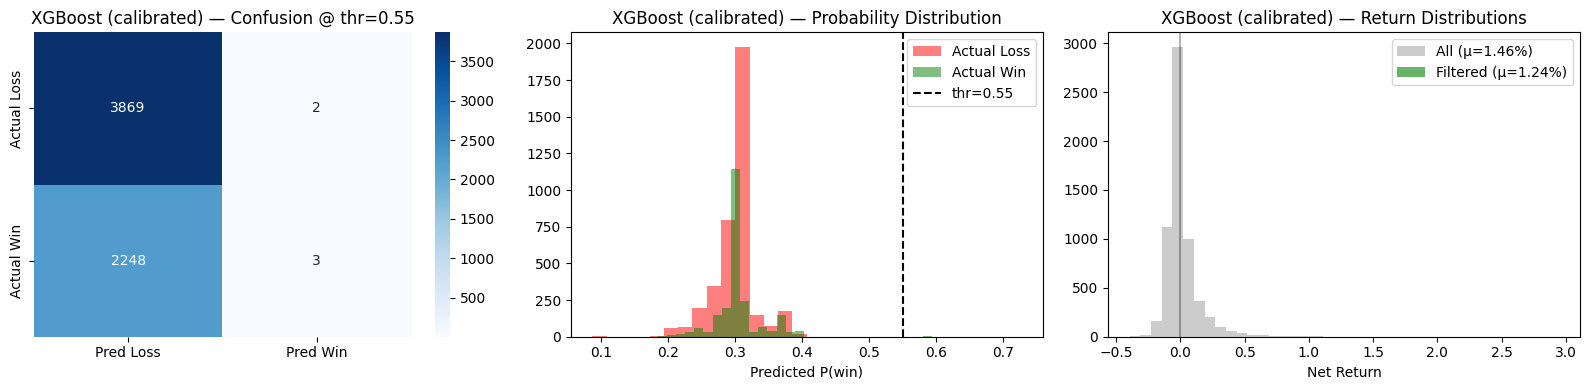


=== XGBoost Test Metrics ===
  auc               : 0.5568
  brier_score       : 0.2345
  precision         : 0.6000
  recall            : 0.0013
  f1                : 0.0027
  trades_taken      : 5
  trades_filtered   : 6117
  pct_filtered      : 0.9992
  base_mean_ret     : 0.0146
  filt_mean_ret     : 0.0124
  base_sharpe       : 1.5268
  filt_sharpe       : 3.9951
  sharpe_lift       : 2.4683


In [19]:
# === Train final XGBoost + Calibrate ===
best_params_xgb = study_xgb.best_params
final_xgb = XGBClassifier(
    **best_params_xgb,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0,
)

# Wrap with calibration (isotonic) so probabilities are meaningful for sizing
calibrated_xgb = CalibratedClassifierCV(
    final_xgb,
    method='isotonic',
    cv=3,            # internal CV for calibration
)
calibrated_xgb.fit(X_train_scaled, y_train, sample_weight=train_weights)

# Evaluate on test set
y_proba_xgb = calibrated_xgb.predict_proba(X_test_scaled)[:, 1]

metrics_xgb = plot_evaluation('XGBoost (calibrated)', y_test, y_proba_xgb, returns_test, threshold=0.55)
print("\n=== XGBoost Test Metrics ===")
for k, v in metrics_xgb.items():
    print(f"  {k:18s}: {v:.4f}" if isinstance(v, float) else f"  {k:18s}: {v}")

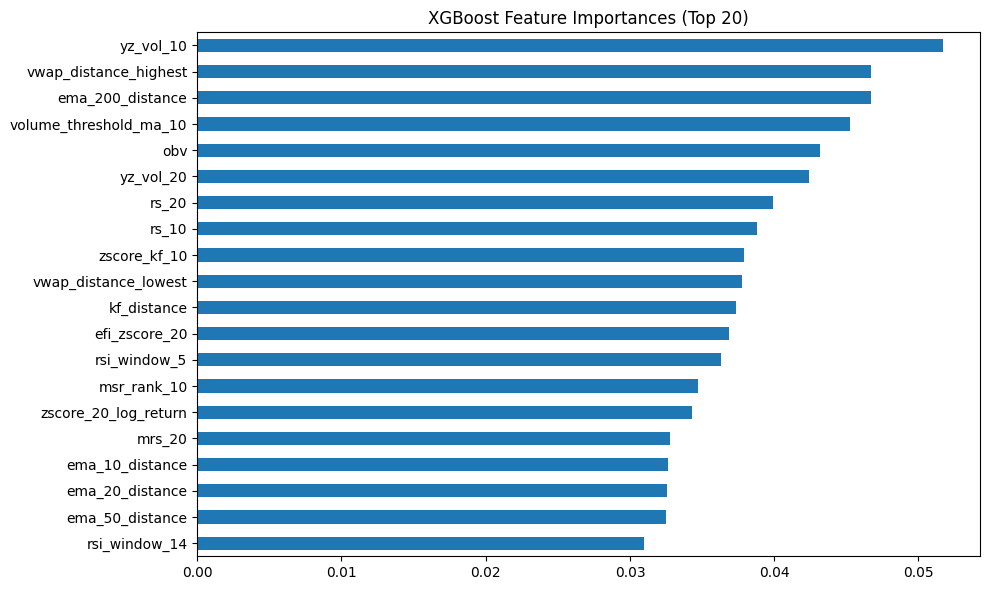

yz_vol_10                 0.051680
vwap_distance_highest     0.046716
ema_200_distance          0.046686
volume_threshold_ma_10    0.045238
obv                       0.043151
yz_vol_20                 0.042416
rs_20                     0.039907
rs_10                     0.038796
zscore_kf_10              0.037919
vwap_distance_lowest      0.037739
kf_distance               0.037348
efi_zscore_20             0.036845
rsi_window_5              0.036290
msr_rank_10               0.034732
zscore_20_log_return      0.034300
mrs_20                    0.032796
ema_10_distance           0.032636
ema_20_distance           0.032547
ema_50_distance           0.032506
rsi_window_14             0.030943
volume_threshold_ma_20    0.030409
mrs_10                    0.029828
efi_zscore_10             0.029365
msr_rank_20               0.029355
zscore_10_log_return      0.028396
mfi_21                    0.028339
zscore_kf_20              0.026696
dc_tmv                    0.026421
dtype: float32

Save

In [20]:
# === Feature importance (from underlying XGBoost) ===
final_xgb.fit(X_train_scaled, y_train, sample_weight=train_weights)
fi_xgb = pd.Series(
    final_xgb.feature_importances_,
    index=X_train_scaled.columns,
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fi_xgb.head(20).plot(kind='barh')
plt.title('XGBoost Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(fi_xgb)

# Save
os.makedirs('../models', exist_ok=True)
ts = datetime.now().strftime('%Y%m%d')
final_xgb.save_model(f'../models/xgboost_meta_{ts}.ubj')
print(f"\nSaved: ../models/xgboost_meta_{ts}.ubj")

# 12. Train LightGBM (same pipeline)

In [21]:
from lightgbm import LGBMClassifier

def objective_lgbm(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600, step=50),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 63),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight':      'balanced',
        'random_state':      42,
        'verbosity':         -1,
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(
        model,
        X_train_scaled, y_train,
        cv=purged_cv.split(X_train_scaled),
        scoring='roc_auc',
        n_jobs=-1,
        params={'sample_weight': train_weights},
    )
    return scores.mean()

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=80, show_progress_bar=True)

print(f"\nBest LGBM CV AUC: {study_lgbm.best_value:.4f}")
print("Best params:", study_lgbm.best_params)

[I 2026-04-30 22:56:32,175] A new study created in memory with name: no-name-f1257089-0eec-4a4a-82cb-0a8636164dfc


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-04-30 22:56:36,438] Trial 0 finished with value: 0.4960512353510893 and parameters: {'n_estimators': 300, 'learning_rate': 0.17254716573280354, 'num_leaves': 50, 'max_depth': 5, 'min_child_samples': 21, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.08499808989183001, 'reg_lambda': 0.0006440507553993703}. Best is trial 0 with value: 0.4960512353510893.
[I 2026-04-30 22:56:47,574] Trial 1 finished with value: 0.5003566820345854 and parameters: {'n_estimators': 450, 'learning_rate': 0.010636066512540286, 'num_leaves': 62, 'max_depth': 7, 'min_child_samples': 25, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 2.716051144654844e-06, 'reg_lambda': 0.00015777981883364995}. Best is trial 1 with value: 0.5003566820345854.
[I 2026-04-30 22:56:49,342] Trial 2 finished with value: 0.5107448980333149 and parameters: {'n_estimators': 300, 'learning_rate': 0.023927528765580634, 'num_leaves': 44, 'max_depth': 3, 'm

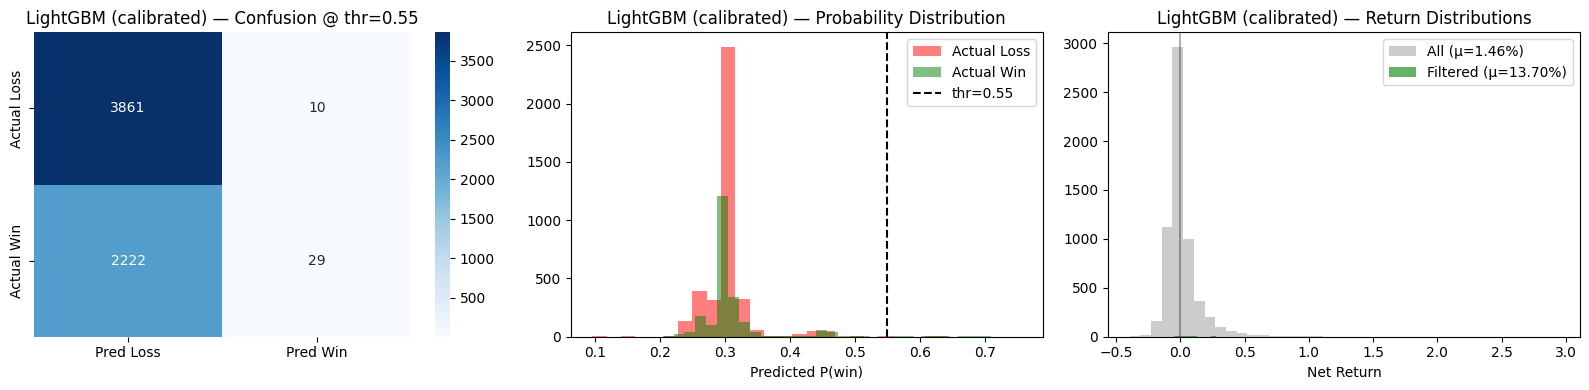

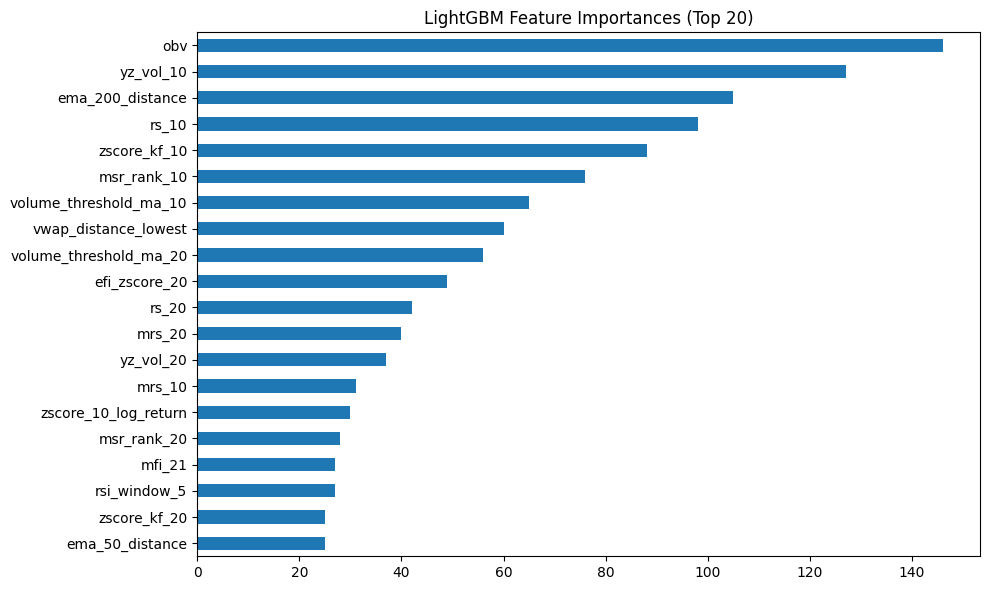


Saved: ../models/lightgbm_meta_20260430.txt


In [22]:
final_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    objective='binary',
    class_weight='balanced',
    random_state=42,
    verbosity=-1,
)

calibrated_lgbm = CalibratedClassifierCV(final_lgbm, method='isotonic', cv=3)
calibrated_lgbm.fit(X_train_scaled, y_train, sample_weight=train_weights)

y_proba_lgbm = calibrated_lgbm.predict_proba(X_test_scaled)[:, 1]
metrics_lgbm = plot_evaluation('LightGBM (calibrated)', y_test, y_proba_lgbm, returns_test, threshold=0.55)

# Feature importance
final_lgbm.fit(X_train_scaled, y_train, sample_weight=train_weights)
fi_lgbm = pd.Series(final_lgbm.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi_lgbm.head(20).plot(kind='barh')
plt.title('LightGBM Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save
final_lgbm.booster_.save_model(f'../models/lightgbm_meta_{ts}.txt')
print(f"\nSaved: ../models/lightgbm_meta_{ts}.txt")

# 13. Train CatBoost (same pipeline)

In [27]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

def objective_cat(trial):
    """Purged ROC-AUC folds without sklearn.cross_val_score (avoids sklearn 1.6+ get_tags/__sklearn_tags__ on CatBoost)."""

    def _rows(arr, idx):
        """Index rows whether ``arr`` is pandas (iloc) or numpy."""
        return arr.iloc[idx] if hasattr(arr, "iloc") else np.asarray(arr)[idx]

    params = {
        'objective':           'Logloss',
        'eval_metric':         'AUC',
        'iterations':          trial.suggest_int('iterations', 100, 600, step=50),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':               trial.suggest_int('depth', 3, 7),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength':     trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 5),
        'auto_class_weights':  'Balanced',
        'random_seed':         42,
        'verbose':             False,
    }
    scores = []
    for train_idx, val_idx in purged_cv.split(X_train_scaled):
        # Match cross_val_sample_weight behavior without routing CatBoost through sklearn CV utilities.
        m = CatBoostClassifier(**params)
        X_tr = _rows(X_train_scaled, train_idx)
        X_va = _rows(X_train_scaled, val_idx)
        y_tr = _rows(y_train, train_idx)
        y_va = _rows(y_train, val_idx)
        w_tr = _rows(train_weights, train_idx)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        proba = m.predict_proba(X_va)[:, 1]
        scores.append(roc_auc_score(y_va, proba))
    return float(np.mean(scores))


study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=60, show_progress_bar=True)

print(f"\nBest CatBoost CV AUC: {study_cat.best_value:.4f}")
print("Best params:", study_cat.best_params)

[I 2026-04-30 23:31:44,820] A new study created in memory with name: no-name-4b2e957f-4532-4d8d-8f8e-7d059723950a


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-04-30 23:31:47,233] Trial 0 finished with value: 0.4982283699831326 and parameters: {'iterations': 300, 'learning_rate': 0.17254716573280354, 'depth': 6, 'l2_leaf_reg': 0.24810409748678114, 'random_strength': 0.004207988669606638, 'bagging_temperature': 0.7799726016810132}. Best is trial 0 with value: 0.4982283699831326.
[I 2026-04-30 23:31:48,125] Trial 1 finished with value: 0.49556697133012745 and parameters: {'iterations': 100, 'learning_rate': 0.13394334706750485, 'depth': 6, 'l2_leaf_reg': 0.6796578090758157, 'random_strength': 0.0012087541473056963, 'bagging_temperature': 4.8495492608099715}. Best is trial 0 with value: 0.4982283699831326.
[I 2026-04-30 23:31:50,729] Trial 2 finished with value: 0.5139659874330657 and parameters: {'iterations': 550, 'learning_rate': 0.018891200276189398, 'depth': 3, 'l2_leaf_reg': 0.00541524411940254, 'random_strength': 0.016480446427978974, 'bagging_temperature': 2.6237821581611893}. Best is trial 2 with value: 0.5139659874330657.
[I 20

CalibratedClassifierCV skipped (CatBoost missing __sklearn_tags__). Run: pip install -U 'catboost>=1.2.9'. Using uncalibrated proba.


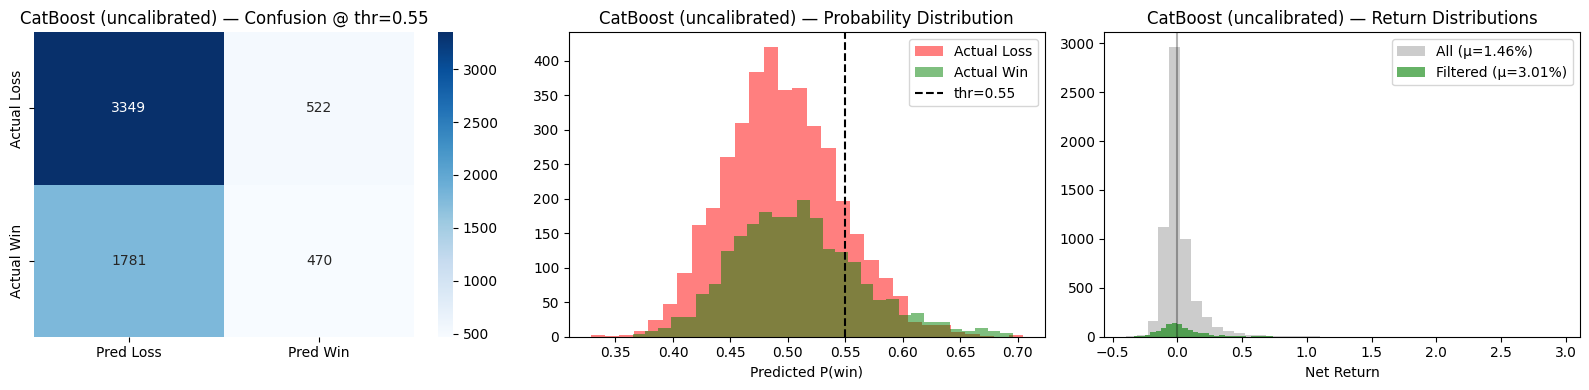

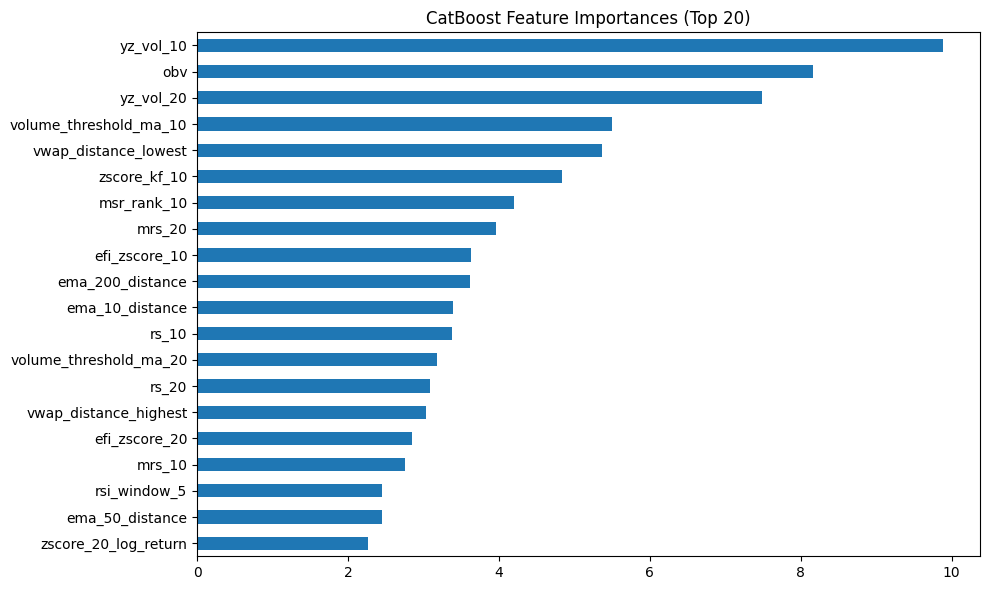


Saved: ../models/catboost_meta_20260430.cbm


In [28]:
final_cat = CatBoostClassifier(
    **study_cat.best_params,
    objective='Logloss',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False,
)

# CalibratedClassifierCV uses sklearn tagging (needs catboost>=1.2.9 with sklearn 1.6+).
try:
    calibrated_cat = CalibratedClassifierCV(final_cat, method='isotonic', cv=3)
    calibrated_cat.fit(X_train_scaled, y_train, sample_weight=train_weights)
    y_proba_cat = calibrated_cat.predict_proba(X_test_scaled)[:, 1]
    cat_eval_name = 'CatBoost (calibrated)'
    _cat_fit_for_fi = True
except AttributeError as e:
    if '__sklearn_tags__' not in str(e):
        raise
    print(
        "CalibratedClassifierCV skipped (CatBoost missing __sklearn_tags__). "
        "Run: pip install -U 'catboost>=1.2.9'. Using uncalibrated proba."
    )
    final_cat.fit(X_train_scaled, y_train, sample_weight=train_weights)
    y_proba_cat = final_cat.predict_proba(X_test_scaled)[:, 1]
    cat_eval_name = 'CatBoost (uncalibrated)'
    _cat_fit_for_fi = False

metrics_cat = plot_evaluation(cat_eval_name, y_test, y_proba_cat, returns_test, threshold=0.55)

# Feature importance
if _cat_fit_for_fi:
    final_cat.fit(X_train_scaled, y_train, sample_weight=train_weights)
fi_cat = pd.Series(final_cat.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi_cat.head(20).plot(kind='barh')
plt.title('CatBoost Feature Importances (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

final_cat.save_model(f'../models/catboost_meta_{ts}.cbm')
print(f"\nSaved: ../models/catboost_meta_{ts}.cbm")

# 14. Model Comparison & Probability Threshold Analysis

Choose the **probability threshold** that maximizes Sharpe lift on the test set, not just accuracy.


In [29]:
# === Side-by-side comparison ===
comparison = pd.DataFrame({
    'XGBoost':  metrics_xgb,
    'LightGBM': metrics_lgbm,
    'CatBoost': metrics_cat,
}).T

display_cols = ['auc', 'brier_score', 'precision', 'recall', 'f1',
                'trades_taken', 'pct_filtered',
                'base_mean_ret', 'filt_mean_ret',
                'base_sharpe', 'filt_sharpe', 'sharpe_lift']
print("=== Model Comparison (Test Set) ===")
print(comparison[display_cols].round(4))

=== Model Comparison (Test Set) ===
             auc  brier_score  precision  recall      f1  trades_taken  \
XGBoost   0.5568       0.2345     0.6000  0.0013  0.0027           5.0   
LightGBM  0.5548       0.2333     0.7436  0.0129  0.0253          39.0   
CatBoost  0.5611       0.2468     0.4738  0.2088  0.2899         992.0   

          pct_filtered  base_mean_ret  filt_mean_ret  base_sharpe  \
XGBoost         0.9992         0.0146         0.0124       1.5268   
LightGBM        0.9936         0.0146         0.1370       1.5268   
CatBoost        0.8380         0.0146         0.0301       1.5268   

          filt_sharpe  sharpe_lift  
XGBoost        3.9951       2.4683  
LightGBM       9.0208       7.4940  
CatBoost       2.6571       1.1304  


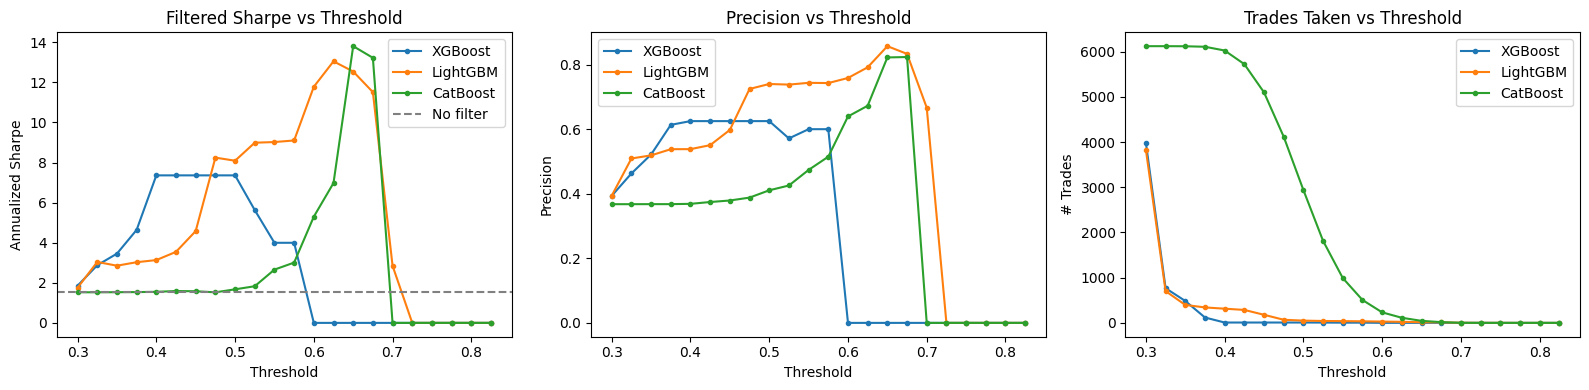


=== Optimal Threshold per Model (by filtered Sharpe) ===
XGBoost    | best thr=0.40 | filt_sharpe=7.358 | trades_taken=8 | precision=0.625
LightGBM   | best thr=0.63 | filt_sharpe=13.047 | trades_taken=24 | precision=0.792
CatBoost   | best thr=0.65 | filt_sharpe=13.803 | trades_taken=45 | precision=0.822


In [30]:
# === Threshold Sweep ===
def threshold_sweep(y_true, y_proba, returns, thresholds=np.arange(0.3, 0.85, 0.025)):
    rows = []
    for thr in thresholds:
        m = evaluate_meta_model(y_true, y_proba, returns, threshold=thr)
        m['threshold'] = thr
        rows.append(m)
    return pd.DataFrame(rows)

sweeps = {
    'XGBoost':  threshold_sweep(y_test, y_proba_xgb,  returns_test),
    'LightGBM': threshold_sweep(y_test, y_proba_lgbm, returns_test),
    'CatBoost': threshold_sweep(y_test, y_proba_cat,  returns_test),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for name, sweep in sweeps.items():
    axes[0].plot(sweep['threshold'], sweep['filt_sharpe'], label=name, marker='o', markersize=3)
    axes[1].plot(sweep['threshold'], sweep['precision'],   label=name, marker='o', markersize=3)
    axes[2].plot(sweep['threshold'], sweep['trades_taken'], label=name, marker='o', markersize=3)

# Reference: base (no-filter) Sharpe
axes[0].axhline(metrics_xgb['base_sharpe'], color='gray', linestyle='--', label='No filter')
axes[0].set_title('Filtered Sharpe vs Threshold')
axes[0].set_xlabel('Threshold');  axes[0].set_ylabel('Annualized Sharpe');  axes[0].legend()

axes[1].set_title('Precision vs Threshold')
axes[1].set_xlabel('Threshold');  axes[1].set_ylabel('Precision');  axes[1].legend()

axes[2].set_title('Trades Taken vs Threshold')
axes[2].set_xlabel('Threshold');  axes[2].set_ylabel('# Trades');  axes[2].legend()

plt.tight_layout()
plt.show()

# Best threshold per model (by Sharpe lift)
print("\n=== Optimal Threshold per Model (by filtered Sharpe) ===")
for name, sweep in sweeps.items():
    best = sweep.loc[sweep['filt_sharpe'].idxmax()]
    print(f"{name:10s} | best thr={best['threshold']:.2f} | "
          f"filt_sharpe={best['filt_sharpe']:.3f} | "
          f"trades_taken={int(best['trades_taken'])} | "
          f"precision={best['precision']:.3f}")

# 15. Calibration Quality

A well-calibrated model has predicted probabilities that match observed frequencies. This matters because **position sizing should use calibrated probabilities** (e.g., for Kelly sizing).


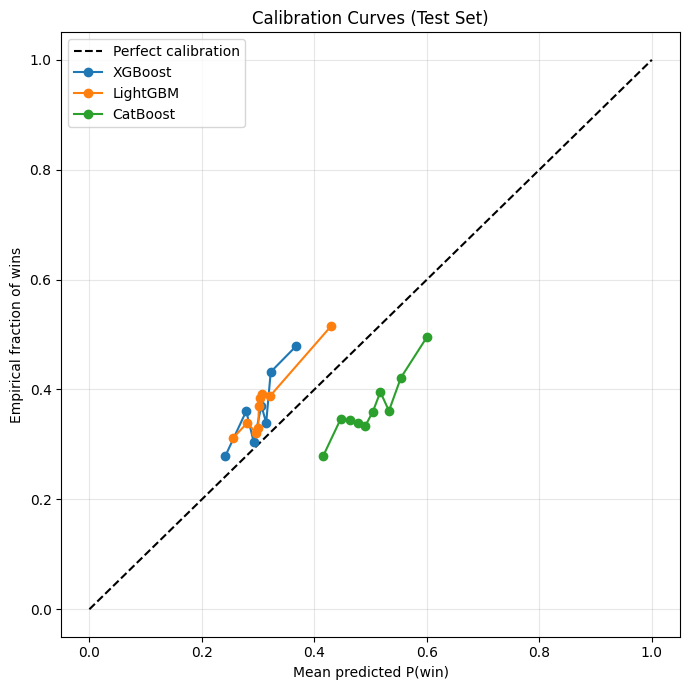

In [31]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

for name, proba in [('XGBoost', y_proba_xgb),
                    ('LightGBM', y_proba_lgbm),
                    ('CatBoost', y_proba_cat)]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)

ax.set_xlabel('Mean predicted P(win)')
ax.set_ylabel('Empirical fraction of wins')
ax.set_title('Calibration Curves (Test Set)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 16. Position Sizing via Calibrated Probabilities

Now that probabilities are calibrated, we can use them for **Kelly-style sizing**.


Train avg win:  18.207%
Train avg loss: -5.518%
Win/Loss ratio: 3.30


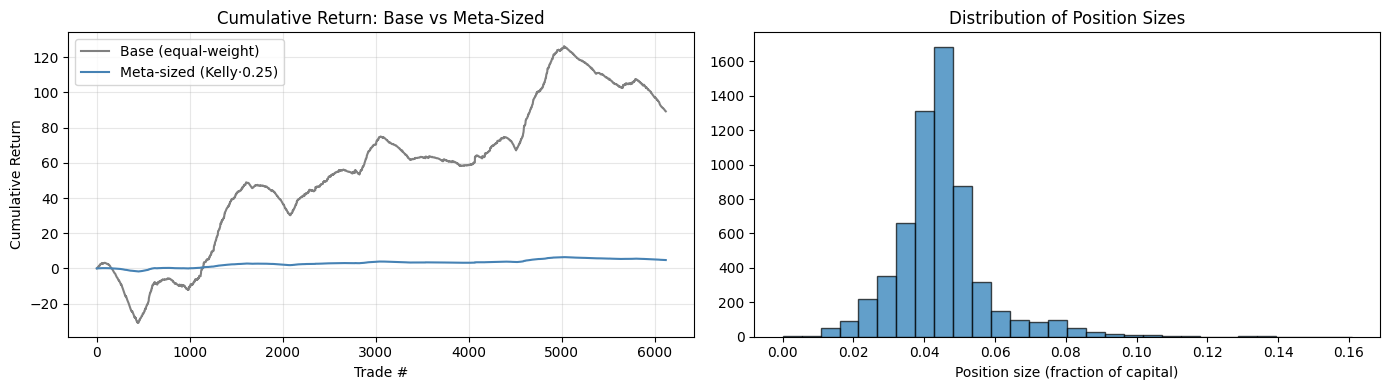


Base returns:    Sharpe=1.527
Sized returns:   Sharpe=1.592
% trades sized > 0: 100.0%


In [32]:
def kelly_size(p_win: np.ndarray, avg_win: float, avg_loss: float, kelly_fraction: float = 0.25):
    """
    Compute fractional-Kelly position size given calibrated win probability.
    avg_win, avg_loss should be POSITIVE numbers (use abs of avg loss).
    Returns size in [0, kelly_fraction].
    """
    b = avg_win / max(avg_loss, 1e-9)
    f = (p_win * (b + 1) - 1) / b
    return np.clip(f, 0, 1) * kelly_fraction

# Use historical avg win/loss from training
train_winners = training_df.loc[train_mask & (training_df['Y']==1), 'net_return']
train_losers  = training_df.loc[train_mask & (training_df['Y']==0), 'net_return']
avg_win  = train_winners.mean()
avg_loss = abs(train_losers.mean())

print(f"Train avg win:  {avg_win:.3%}")
print(f"Train avg loss: -{avg_loss:.3%}")
print(f"Win/Loss ratio: {avg_win/avg_loss:.2f}")

# Apply to test set using ENSEMBLE probability
ensemble_proba = (y_proba_xgb + y_proba_lgbm + y_proba_cat) / 3
sizes = kelly_size(ensemble_proba, avg_win, avg_loss, kelly_fraction=0.25)

# Sized P&L
sized_returns = sizes * returns_test.values

# Compare base (equal weight) vs sized
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(np.cumsum(returns_test.values), label='Base (equal-weight)', color='gray')
ax[0].plot(np.cumsum(sized_returns), label='Meta-sized (Kelly·0.25)', color='steelblue')
ax[0].set_title('Cumulative Return: Base vs Meta-Sized')
ax[0].set_xlabel('Trade #')
ax[0].set_ylabel('Cumulative Return')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].hist(sizes, bins=30, edgecolor='black', alpha=0.7)
ax[1].set_title('Distribution of Position Sizes')
ax[1].set_xlabel('Position size (fraction of capital)')
plt.tight_layout()
plt.show()

print(f"\nBase returns:    Sharpe={returns_test.mean()/(returns_test.std()+1e-9)*np.sqrt(252):.3f}")
print(f"Sized returns:   Sharpe={pd.Series(sized_returns).mean()/(pd.Series(sized_returns).std()+1e-9)*np.sqrt(252):.3f}")
print(f"% trades sized > 0: {(sizes > 0).mean()*100:.1f}%")

# 17. Save Calibrated Models + Scaler

In [33]:
import joblib

artifacts_dir = '../models'
os.makedirs(artifacts_dir, exist_ok=True)
ts = datetime.now().strftime('%Y%m%d')

# Save calibrated models (these output proper probabilities)
joblib.dump(calibrated_xgb,  f'{artifacts_dir}/calibrated_xgb_{ts}.joblib')
joblib.dump(calibrated_lgbm, f'{artifacts_dir}/calibrated_lgbm_{ts}.joblib')
joblib.dump(calibrated_cat,  f'{artifacts_dir}/calibrated_cat_{ts}.joblib')

# Save scaler + feature columns (essential for inference)
joblib.dump(scaler, f'{artifacts_dir}/scaler_{ts}.joblib')

with open(f'{artifacts_dir}/feature_columns_{ts}.json', 'w') as f:
    json.dump({
        'features':     training_feature_columns,
        'train_end':    TRAIN_END_DATE,
        'cost':         ROUND_TRIP_COST,
        'edge':         MIN_RETURN_EDGE,
        'embargo_days': EMBARGO_DAYS,
    }, f, indent=2)

print(f"All artifacts saved to {artifacts_dir}/ with timestamp {ts}")

All artifacts saved to ../models/ with timestamp 20260430


# 📋 Summary of Changes

| # | Issue (Original) | Fix Applied |
|---|---|---|
| 1 | `train_test_split(shuffle=True)` | Chronological split with embargo |
| 2 | `next_5d_*`, `next_3d_*` features | Removed all look-ahead features |
| 3 | SMOTE on time-series data | `class_weight='balanced'` / `scale_pos_weight` |
| 4 | Standard K-Fold CV | Purged & Embargoed K-Fold |
| 5 | No sample weights | López de Prado uniqueness weights |
| 6 | Raw probabilities | Isotonic calibration |
| 7 | Accuracy-driven optimization | AUC + Sharpe-lift driven |
| 8 | `Y = return > 0` | Net return > threshold (with costs) |
| 9 | No threshold analysis | Sweep + ensemble + Kelly sizing |
| 10 | No effective sample size check | Compute & report |

## 🚦 Next Steps

1. **Walk-forward validation** — re-train every quarter, test on next quarter
2. **SHAP analysis** — understand WHY each trade is filtered
3. **Live shadow testing** — paper trade meta-filtered signals for 1-3 months before going live
4. **Re-training cadence** — alpha decays; re-train every 3-6 months
5. **Ensemble weighting** — try stacking instead of simple average

## ⚠️ Honest Expectations

- OOS AUC of 0.55-0.62 is realistic for VN equity meta-labeling
- Sharpe lift of 0.2-0.5 is a good outcome
- Expect 30-50% degradation from backtest to live
- If AUC > 0.70, **suspect leakage** — re-audit features
